In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (7,3), 'figure.dpi': 120})

In [6]:
link='https://drive.google.com/file/d/1g74Mz3wnCH3bqf7UlecT11cz4dMxjQ4C/view?usp=sharing'
url = 'https://drive.google.com/uc?import=download&id=' + link.split('/')[-2]
df = pd.read_csv(url, encoding= "unicode_escape")

In [7]:
df.sample(10)

,Times_Pregnant,Glucose_Concentration,Blood_Pressure,Skin_thickness,insulin,BMI,DPF,Age,Class
623,0,94,70,27,115,43.5,0.347,21,0
476,2,105,80,45,191,33.7,0.711,29,1
29,5,117,92,0,0,34.1,0.337,38,0
678,3,121,52,0,0,36.0,0.127,25,1
477,7,114,76,17,110,23.8,0.466,31,0
684,5,136,82,0,0,0.0,0.640,69,0
46,1,146,56,0,0,29.7,0.564,29,0
425,4,184,78,39,277,37.0,0.264,31,1
548,1,164,82,43,67,32.8,0.341,50,0
194,8,85,55,20,0,24.4,0.136,42,0


In [8]:
df['Class'].value_counts()

Class
0    500
1    268
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Times_Pregnant          768 non-null    int64  
 1    Glucose_Concentration  768 non-null    int64  
 2   Blood_Pressure          768 non-null    int64  
 3   Skin_thickness          768 non-null    int64  
 4   insulin                 768 non-null    int64  
 5   BMI                     768 non-null    float64
 6   DPF                     768 non-null    float64
 7   Age                     768 non-null    int64  
 8   Class                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [13]:
df.isna().sum()

Times_Pregnant            0
 Glucose_Concentration    0
Blood_Pressure            0
Skin_thickness            0
insulin                   0
BMI                       0
DPF                       0
Age                       0
Class                     0
dtype: int64

In [14]:
df.tail(5)

,Times_Pregnant,Glucose_Concentration,Blood_Pressure,Skin_thickness,insulin,BMI,DPF,Age,Class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [15]:
X = df.iloc[:,0:-1].values
y = df['Class'].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.3,random_state= 0)

In [16]:
from imblearn.over_sampling import SMOTE
X_train, y_train = SMOTE().fit_resample(X_train,y_train)

In [17]:
from sklearn.linear_model import LogisticRegression
model_log = LogisticRegression()
model_log.fit(X_train,y_train)

d:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [19]:
y_pred = model_log.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
acc

0.7532467532467533

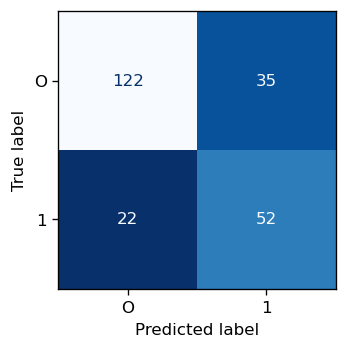

In [24]:
import seaborn as sn
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cn = confusion_matrix(y_test,y_pred)
fig, ax = plt.subplots()
label = ['O','1']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels= label, ax = ax, colorbar= False, cmap = 'Blues_r')

In [25]:
from sklearn.metrics import classification_report
cl = classification_report(y_test,y_pred)
print(cl) 

              precision    recall  f1-score   support

           0       0.85      0.78      0.81       157
           1       0.60      0.70      0.65        74

    accuracy                           0.75       231
   macro avg       0.72      0.74      0.73       231
weighted avg       0.77      0.75      0.76       231



Text(0.4, 0.2, 'AUC: 0.84')

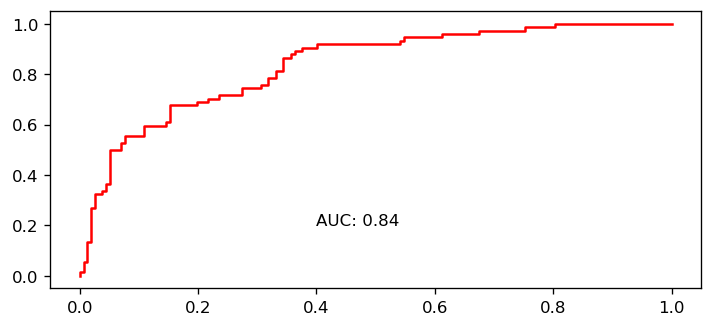

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
y_probabilities = model_log.predict_proba(X_test)[:,-1]
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test,y_probabilities)
plt.plot(false_positive_rate,true_positive_rate, color = 'red')
plt.text(0.4,0.2,'AUC: {:.2f}'.format(roc_auc_score(y_test,y_probabilities)))